# Initialize

In [1]:
import os
import sys

import pandas as pd
import polars as pl
from catboost import CatBoostRegressor

os.chdir("../../")
sys.path.insert(0, os.getcwd())

In [2]:
from morai.experience import charters
from morai.forecast import preprocessors
from morai.utils import custom_logger, helpers

In [105]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

# Charts

## Data

In [4]:
# standard df
df = pd.DataFrame(
    {
        "attained_age": [10, 20, 30, 40, 50, 10, 20, 30, 40, 50],
        "gender": ["M", "M", "M", "M", "M", "F", "F", "F", "F", "F"],
        "actuals": [1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
        "exposures": [50, 50, 50, 50, 50, 100, 100, 100, 100, 100],
    }
)

## Line

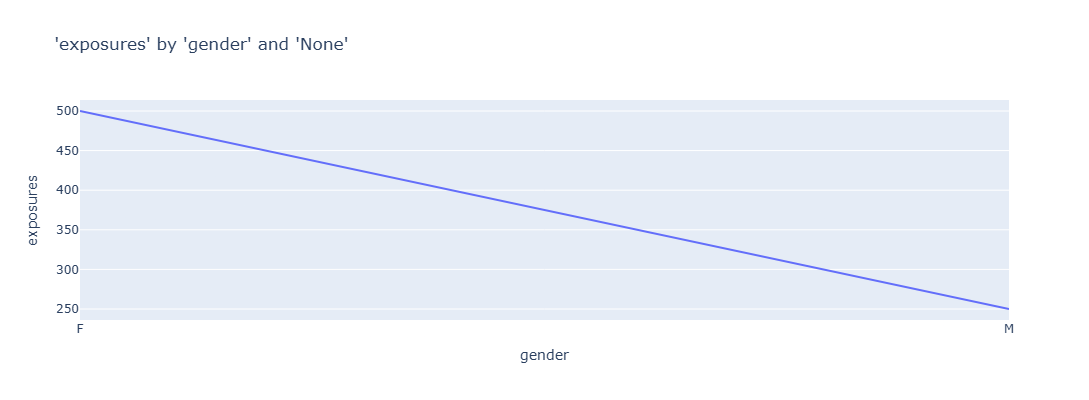

In [5]:
charters.chart(df=df, x_axis="gender", y_axis="exposures", type="line")

## Bar

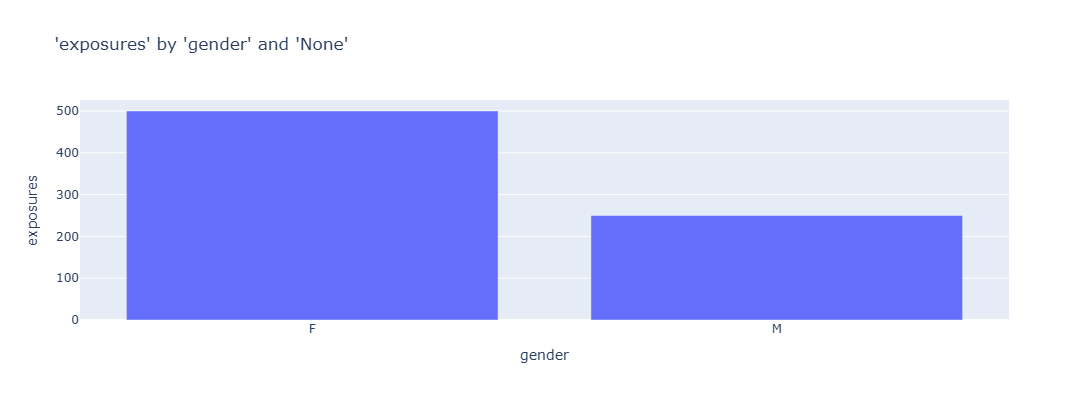

In [8]:
charters.chart(df=df, x_axis="gender", y_axis="exposures", type="bar")

## Heatmap

 2026-01-16 21:38:53 | morai.experience.charters | INFO     | Calculating ratio using [actuals] and [exposures] 


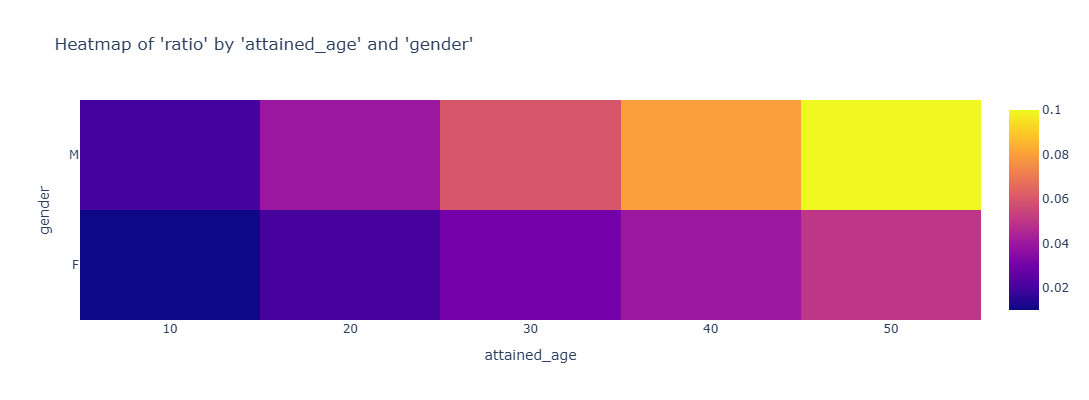

In [14]:
charters.chart(
    df=df, x_axis="attained_age", y_axis="gender", color="ratio", numerator="actuals", denominator="exposures", type="heatmap"
)

## Histogram

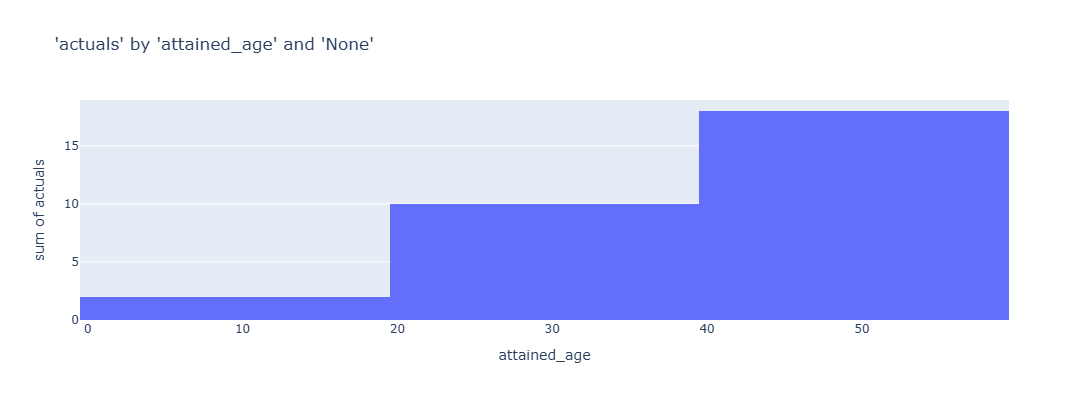

In [15]:
charters.chart(df=df, x_axis="attained_age", y_axis="actuals", type="histogram")

## Area

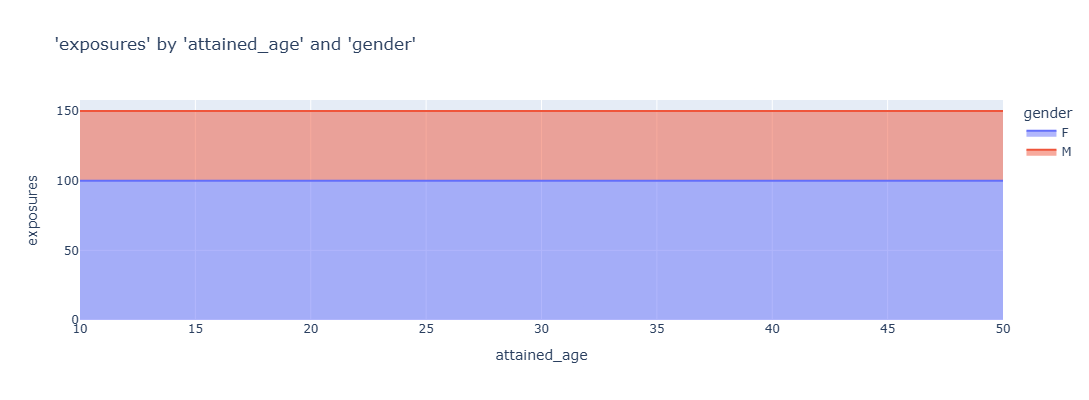

In [16]:
charters.chart(df=df, x_axis="attained_age", y_axis="exposures", color="gender", type="area")

## Contour

 2026-01-16 21:40:16 | morai.experience.charters | INFO     | Calculating ratio using [actuals] and [exposures] 


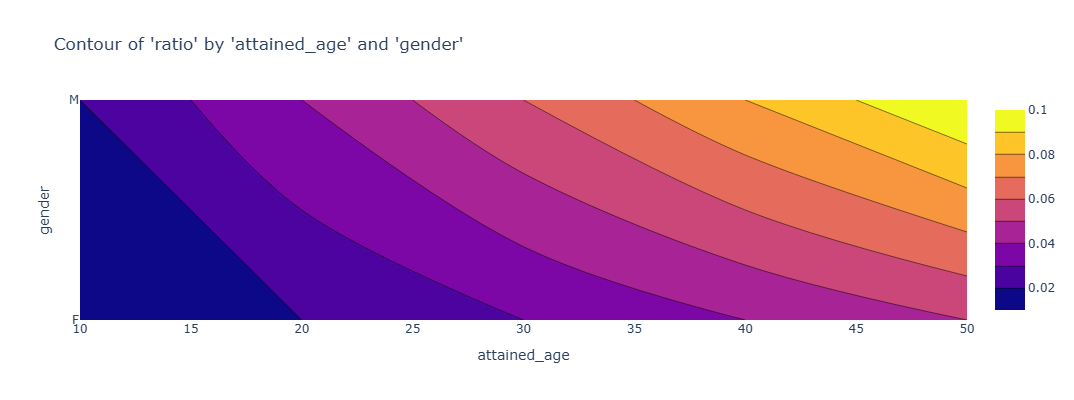

In [17]:
charters.chart(
    df=df, x_axis="attained_age", y_axis="gender", color="ratio", numerator="actuals", denominator="exposures", type="contour"
)

# PDP/ALE

## PDP

This shows an example of how the Partial Dependency Plot could be used

The following shows a group of people that exercise, eat healthy, and age.The actual relationships are as follows:
- every 10 years the rate goes up by 10% starting at .01
- eating unhealthy (0) has 50% higher rate than eating healthy (1)
- non-exercise (0) has 5% higher rate than exercise (1)
- exercise and eating healthy are highly correlated as almost everyone does both rarely does one and not the other.

When looking at the data, a user may say that exercise is highly predictive of the rate. This would be false as there are some people that exercise and do not eat healthy and their rate is much higher than the people that eat healthy. **PDP woul capture this relationship**. A **pairwise** plot would also capture this relationship.

In [106]:
pdp_data = pd.read_csv("tests/files/experience/charters/pdp_example.csv")
feature_dict = {
    "target": ["rate"],
    "weight": ["weight"],
    "ordinal": ["age", "healthy", "exercise"],
}
preprocess_dict = preprocessors.preprocess_data(
    pdp_data,
    feature_dict=feature_dict,
    standardize=False,
    preset="pass",
)
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]
md_encoded = preprocess_dict["md_encoded"]
model_features = preprocess_dict["model_features"]

 2026-06-28 21:51:02 | morai.forecast.preprocessors | INFO     | using 'pass' preset which makes all features passthrough 
 2026-06-28 21:51:02 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2026-06-28 21:51:03 | morai.forecast.preprocessors | INFO     | model weights: ['weight'] 
 2026-06-28 21:51:03 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['exercise', 'age', 'healthy'] 


In [108]:
cat_features = feature_dict["ordinal"]
cat_features = list(set(cat_features) & set(model_features))

In [109]:
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    cat_features=cat_features,
    one_hot_max_size=11,
)
model.fit(X, y, sample_weight=weights, verbose=0)

CatBoostRegressor(cat_features=['exercise', 'age', 'healthy'], depth=8, iterations=2000, learning_rate=0.05, loss_function='RMSE', one_hot_max_size=11)

In [110]:
pdp_data["pred"] = model.predict(X)

In [111]:
pdp_data["rate_weight"] = pdp_data["rate"] * pdp_data["weight"]

### Chart

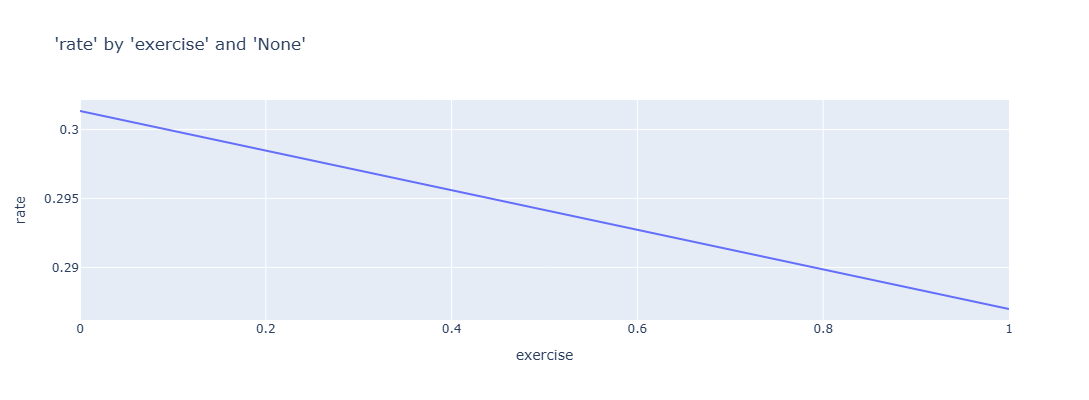

In [112]:
charters.chart(
    df=pdp_data,
    x_axis="exercise",
    y_axis="rate",
)

 2026-06-28 21:51:44 | morai.experience.charters | INFO     | Creating '4' target plots. 


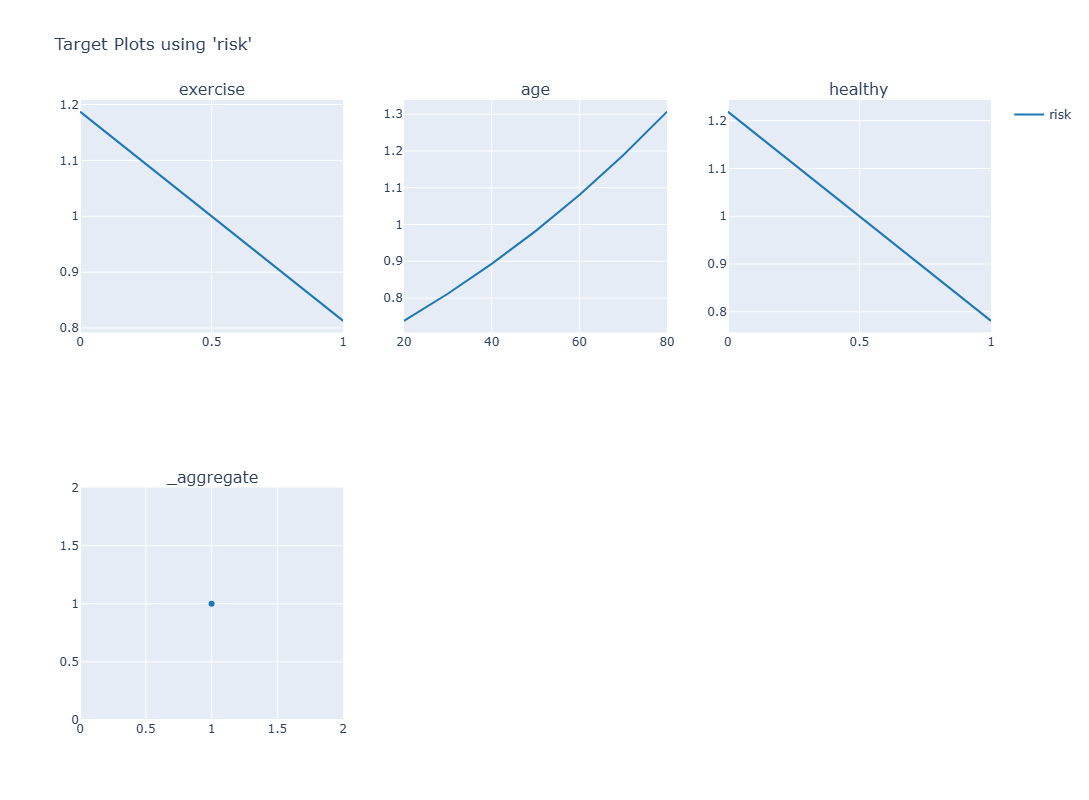

In [113]:
charters.target(
    df=pdp_data,
    target="risk",
    features=["exercise", "age", "healthy"],
    numerator=["rate_weight"],
    denominator=["weight"],
)

### Dependencies

Mortality goes up with age

 2026-06-28 21:51:49 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for partial dependence plot. 
 2026-06-28 21:51:49 | morai.experience.charters | INFO     | Weights: [weight] 
 2026-06-28 21:51:49 | morai.experience.charters | INFO     | x_axis: [age] type: [passthrough] center: [global] 
 2026-06-28 21:51:49 | morai.experience.charters | INFO     | Creating 7 predictions. 


Processing:   0%|          | 0/7 [00:00<?, ?combo/s]

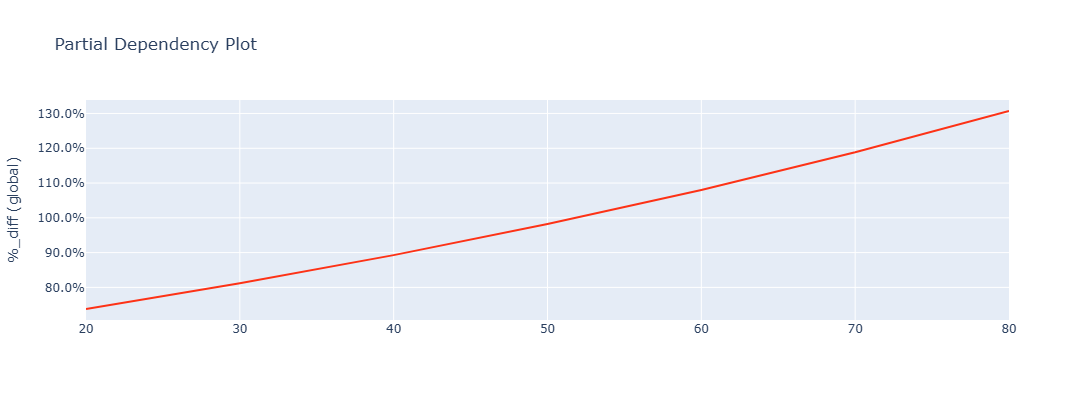

In [114]:
charters.pdp(
    model=model,
    df=md_encoded,
    x_axis="age",
    weight="weight",
    mapping=mapping,
    display=True,
)

Exercise has about 5% better mortality than not exercising

 2026-06-28 21:51:52 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for partial dependence plot. 
 2026-06-28 21:51:52 | morai.experience.charters | INFO     | Weights: [weight] 
 2026-06-28 21:51:52 | morai.experience.charters | INFO     | x_axis: [exercise] type: [passthrough] center: [global] 
 2026-06-28 21:51:52 | morai.experience.charters | INFO     | Creating 2 predictions. 


Processing:   0%|          | 0/2 [00:00<?, ?combo/s]

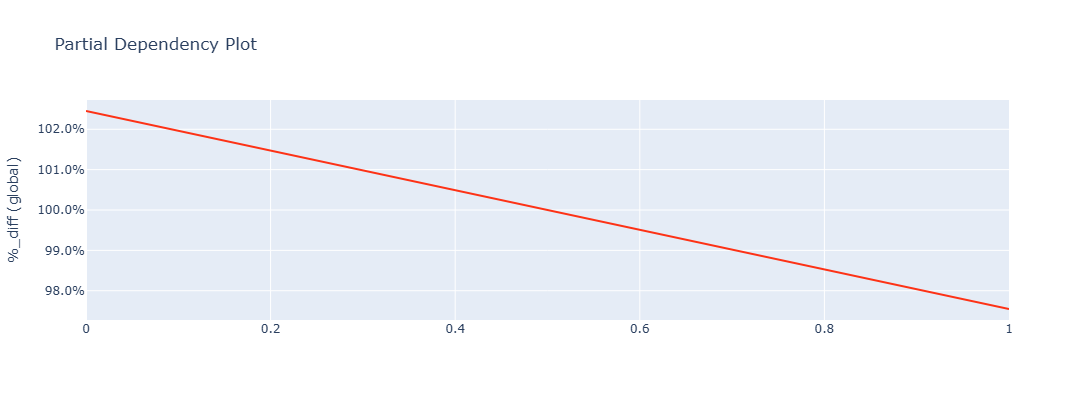

In [115]:
charters.pdp(
    model=model,
    df=md_encoded,
    x_axis="exercise",
    weight="weight",
    mapping=mapping,
    display=True,
)

Eating healthy has about 1.5 better mortality than not eating healthy

 2026-06-23 23:05:56 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for partial dependence plot. 
 2026-06-23 23:05:56 | morai.experience.charters | INFO     | Weights: [weight] 
 2026-06-23 23:05:56 | morai.experience.charters | INFO     | x_axis: [healthy] type: [passthrough] center: [global] 
 2026-06-23 23:05:56 | morai.experience.charters | INFO     | Creating 2 predictions. 


Processing:   0%|          | 0/2 [00:00<?, ?combo/s]

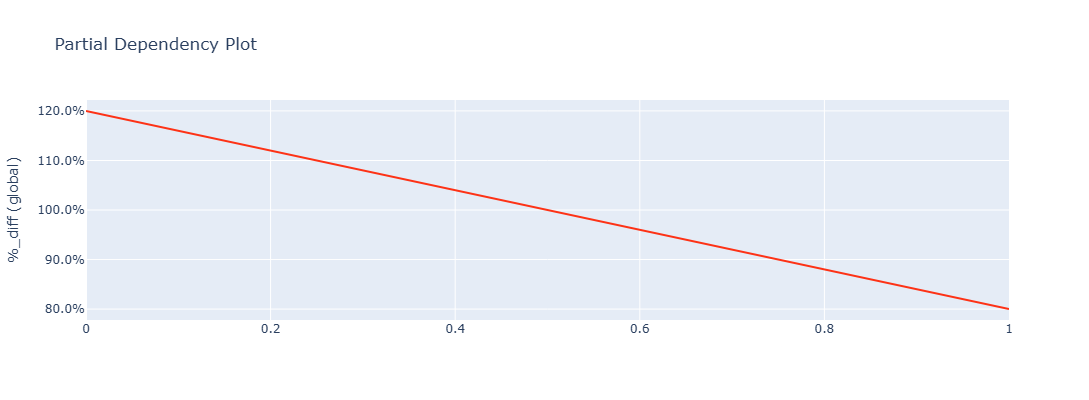

In [95]:
charters.pdp(
    model=model,
    df=md_encoded,
    x_axis="healthy",
    weight="weight",
    mapping=mapping,
    display=True,
)

Pairwise plot shows the marginal increase when not exercising, but large increase when not eating healthy

 2026-06-23 23:08:36 | morai.experience.charters | INFO     | Generating `1` pairwise plots from features 
 2026-06-23 23:08:36 | morai.experience.charters | INFO     | Creating '1' pairwise plots. 


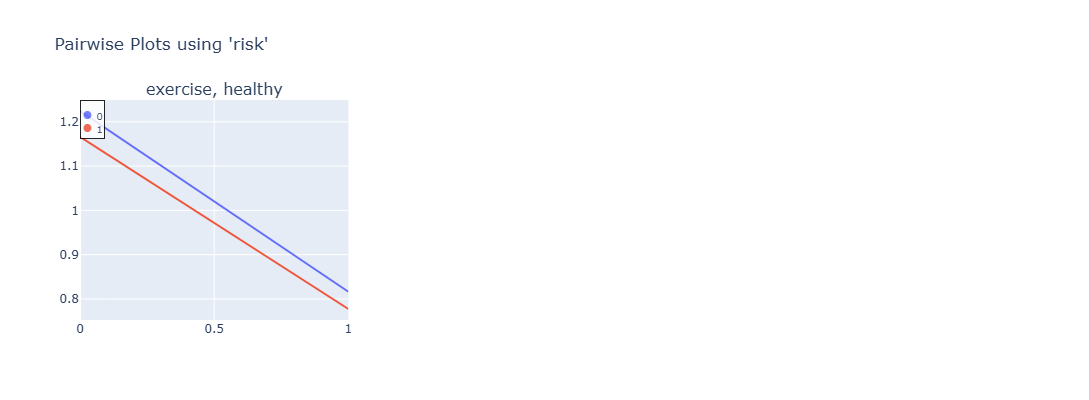

In [96]:
charters.target(
    df=pdp_data,
    target="risk",
    features=["exercise", "healthy"],
    numerator=["rate_weight"],
    denominator=["weight"],
    generate_pairwise=True,
)

## ALE

The following shows a similar example to PDP however there is now a correlation between the healthy and age feature.

The following shows a group of people that exercise, eat healthy, and age.

The actual relationships are as follows:
- every 10 years the rate goes up by 7% when healthy and 13% when unhealthy
- eating unhealthy (0) has 50% higher rate than eating healthy (1)
- non-exercise (0) has 5% higher rate than exercise (1)
- exercise and eating healthy are highly correlated as almost everyone does both rarely does one and not the other.

The cons with PDP are:
- PDP provides weights to unlikely events while ALE is providing weight to locally similar events
- When features are correlated ALE will be able to isolate the driver better


In [97]:
ale_data = pd.read_csv("tests/files/experience/charters/ale_example.csv")
feature_dict = {
    "target": ["rate"],
    "weight": ["weight"],
    "ordinal": ["age", "healthy", "exercise"],
}
preprocess_dict = preprocessors.preprocess_data(
    ale_data,
    feature_dict=feature_dict,
    standardize=False,
    preset="pass",
)
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]
md_encoded = preprocess_dict["md_encoded"]
model_features = preprocess_dict["model_features"]

 2026-06-23 23:09:00 | morai.forecast.preprocessors | INFO     | using 'pass' preset which makes all features passthrough 
 2026-06-23 23:09:00 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2026-06-23 23:09:00 | morai.forecast.preprocessors | INFO     | model weights: ['weight'] 
 2026-06-23 23:09:00 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['exercise', 'age', 'healthy'] 


In [98]:
cat_features = feature_dict["ordinal"]
cat_features = list(set(cat_features) & set(model_features))

In [99]:
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    cat_features=cat_features,
    one_hot_max_size=11,
)
model.fit(X, y, sample_weight=weights, verbose=0)

CatBoostRegressor(cat_features=['exercise', 'age', 'healthy'], depth=8, iterations=2000, learning_rate=0.05, loss_function='RMSE', one_hot_max_size=11)

### Dependencies

In [100]:
pdp_df=charters.pdp(
    model=model,
    df=md_encoded,
    x_axis="age",
    weight="weight",
    mapping=mapping,
    display=False,
)

 2026-06-23 23:09:04 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for partial dependence plot. 
 2026-06-23 23:09:04 | morai.experience.charters | INFO     | Weights: [weight] 
 2026-06-23 23:09:04 | morai.experience.charters | INFO     | x_axis: [age] type: [passthrough] center: [global] 
 2026-06-23 23:09:04 | morai.experience.charters | INFO     | Creating 7 predictions. 


Processing:   0%|          | 0/7 [00:00<?, ?combo/s]

In [103]:
ale_df=charters.ale(
    model=model,
    df=md_encoded,
    x_axis="age",
    weight="weight",
    mapping=mapping,
    display=False,
    multiplicative=False,
)

 2026-06-23 23:09:49 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for ALE plot. 
 2026-06-23 23:09:49 | morai.experience.charters | INFO     | Weights: [weight] 
 2026-06-23 23:09:49 | morai.experience.charters | INFO     | x_axis: [age] discrete: [True] log: [False] center: [global] 
 2026-06-23 23:09:49 | morai.experience.charters | INFO     | Creating 6 local-effect predictions. 


Processing:   0%|          | 0/6 [00:00<?, ?combo/s]

Here we see the increase in the slope of the ALE, which is due to more people being unhealthy in later ages which accelerated mortality. The PDP had a constant slope throughout.

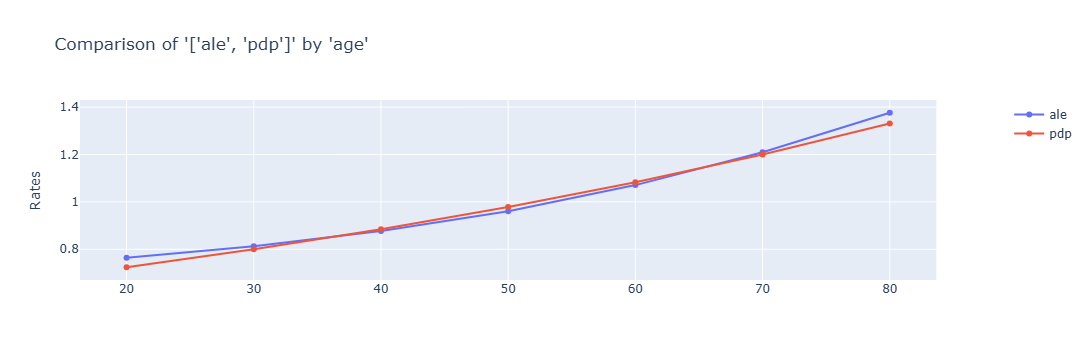

In [104]:
combined_df = pd.concat([
    ale_df.set_index("age")[["%_diff"]].rename(columns={"%_diff": "ale"}),
    pdp_df.set_index("age")[["%_diff"]].rename(columns={"%_diff": "pdp"})
], axis=1).reset_index()
charters.compare_rates(df=combined_df, x_axis="age", rates=["ale","pdp"])

# Reload

In [127]:
import importlib
importlib.reload(charters)

<module 'morai.experience.charters' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\experience\\charters.py'>